# Exploratory Data Analysis - Daphnet FoG Dataset

**Objective:** Analyze the Daphnet dataset to understand FoG patterns and data characteristics.

**Dataset:** 10 Parkinson's patients, 3 accelerometers (ankle, thigh, trunk), 64 Hz sampling rate

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from loaders import DaphnetDatasetLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data
loader = DaphnetDatasetLoader('../../Datasets/Daphnet fog/dataset')
df = loader.load_all_data(verbose=True)

# Add subject and trial identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['trial'] = df['run_id'].apply(lambda x: f'R{x:02d}')

# Filter experimental data only (annotation != 0)
df = df[df['annotation'] != 0].reset_index(drop=True)

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {df['subject'].nunique()}")
print(f"Total duration: {df['time_s'].max():.1f} seconds ({df['time_s'].max()/60:.1f} minutes)")

📁 Encontrados 17 archivos
📊 Cargando datos del dataset Daphnet...



Cargando archivos: 100%|██████████| 17/17 [00:25<00:00,  1.51s/it]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: DaphnetDatasetLoader

📊 Información General:
   Dimensiones: (1917887, 16)
   Filas: 1,917,887
   Columnas: 16
   Memoria: 327.40 MB

👥 Sujetos: 10
📁 Archivos: 17

🚨 Episodios de FoG:
   Muestras con FoG: 110,785 (5.78%)
   Muestras sin FoG: 1,807,102 (94.22%)


Dataset shape: (1140835, 18)
Subjects: 10
Total duration: 2930.0 seconds (48.8 minutes)


## 2. Data Structure

In [3]:
# Display first rows
df.head()

,time_ms,ankle_acc_forward,ankle_acc_vertical,ankle_acc_lateral,thigh_acc_forward,thigh_acc_vertical,thigh_acc_lateral,trunk_acc_forward,trunk_acc_vertical,trunk_acc_lateral,annotation,subject_id,run_id,filename,label,time_s,subject,trial
0,750000,-30,990,326,-45,972,181,-38,1000,29,1,1,1,S01R01.txt,1,750.000,S01,R01
1,750015,-30,1000,356,-18,981,212,-48,1028,29,1,1,1,S01R01.txt,1,750.015,S01,R01
2,750031,-20,990,336,18,981,222,-38,1038,9,1,1,1,S01R01.txt,1,750.031,S01,R01
3,750046,-20,1000,316,36,990,222,-19,1038,9,1,1,1,S01R01.txt,1,750.046,S01,R01
4,750062,0,990,316,36,990,212,-29,1038,29,1,1,1,S01R01.txt,1,750.062,S01,R01


In [4]:
# Data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1140835 entries, 0 to 1140834
Data columns (total 18 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   time_ms             1140835 non-null  int64  
 1   ankle_acc_forward   1140835 non-null  int64  
 2   ankle_acc_vertical  1140835 non-null  int64  
 3   ankle_acc_lateral   1140835 non-null  int64  
 4   thigh_acc_forward   1140835 non-null  int64  
 5   thigh_acc_vertical  1140835 non-null  int64  
 6   thigh_acc_lateral   1140835 non-null  int64  
 7   trunk_acc_forward   1140835 non-null  int64  
 8   trunk_acc_vertical  1140835 non-null  int64  
 9   trunk_acc_lateral   1140835 non-null  int64  
 10  annotation          1140835 non-null  int64  
 11  subject_id          1140835 non-null  int64  
 12  run_id              1140835 non-null  int64  
 13  filename            1140835 non-null  str    
 14  label               1140835 non-null  int64  
 15  time_s              114083

In [5]:
# Statistical summary
df.describe()

,time_ms,ankle_acc_forward,ankle_acc_vertical,ankle_acc_lateral,thigh_acc_forward,thigh_acc_vertical,thigh_acc_lateral,trunk_acc_forward,trunk_acc_vertical,trunk_acc_lateral,annotation,subject_id,run_id,label,time_s
count,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06,1.140835e+06
mean,1.299566e+06,-9.754756e+01,9.968713e+02,2.426220e+02,-2.151868e+00,7.682198e+02,1.465579e+02,5.513867e+01,9.585585e+02,1.709508e+01,1.097109e+00,5.431704e+00,1.234223e+00,1.097109e+00,1.299566e+03
std,6.404573e+05,5.744049e+02,3.623900e+02,3.207129e+02,5.654251e+02,3.673463e+02,2.727563e+02,2.019710e+02,1.960703e+02,2.169134e+02,2.961059e-01,2.889965e+00,4.651775e-01,2.961059e-01,6.404573e+02
min,1.850000e+05,-3.123400e+04,-3.225500e+04,-3.148700e+04,-2.184600e+04,-2.967300e+04,-2.390800e+04,-3.951000e+03,-1.323000e+03,-4.242000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.850000e+02
25%,7.892030e+05,-3.030000e+02,9.110000e+02,1.480000e+02,-3.000000e+02,4.620000e+02,1.000000e+01,-6.700000e+01,9.230000e+02,-1.160000e+02,1.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,7.892030e+02
50%,1.183046e+06,-7.000000e+01,9.900000e+02,2.370000e+02,-2.700000e+01,9.250000e+02,1.410000e+02,3.800000e+01,9.800000e+02,-9.000000e+00,1.000000e+00,5.000000e+00,1.000000e+00,1.000000e+00,1.183046e+03
75%,1.774812e+06,1.210000e+02,1.039000e+03,3.460000e+02,3.000000e+02,9.810000e+02,2.720000e+02,1.740000e+02,1.019000e+03,1.260000e+02,1.000000e+00,8.000000e+00,1.000000e+00,1.000000e+00,1.774812e+03
max,2.930000e+06,2.765100e+04,3.149300e+04,2.943700e+04,2.259600e+04,2.259600e+04,2.259600e+04,6.707000e+03,2.429800e+04,4.300000e+03,2.000000e+00,1.000000e+01,3.000000e+00,2.000000e+00,2.930000e+03


## 3. FoG Distribution Analysis

Annotations: 1 = No FoG, 2 = FoG episode

In [6]:
# Overall FoG distribution
fog_counts = df['annotation'].value_counts().sort_index()
fog_pct = (fog_counts / len(df) * 100).round(2)

print("FoG Distribution:")
print(f"  No FoG (1): {fog_counts[1]:,} samples ({fog_pct[1]}%)")
print(f"  FoG (2):    {fog_counts[2]:,} samples ({fog_pct[2]}%)")
print(f"\nClass imbalance ratio: {fog_counts[1]/fog_counts[2]:.1f}:1")

FoG Distribution:
  No FoG (1): 1,030,050 samples (90.29%)
  FoG (2):    110,785 samples (9.71%)

Class imbalance ratio: 9.3:1


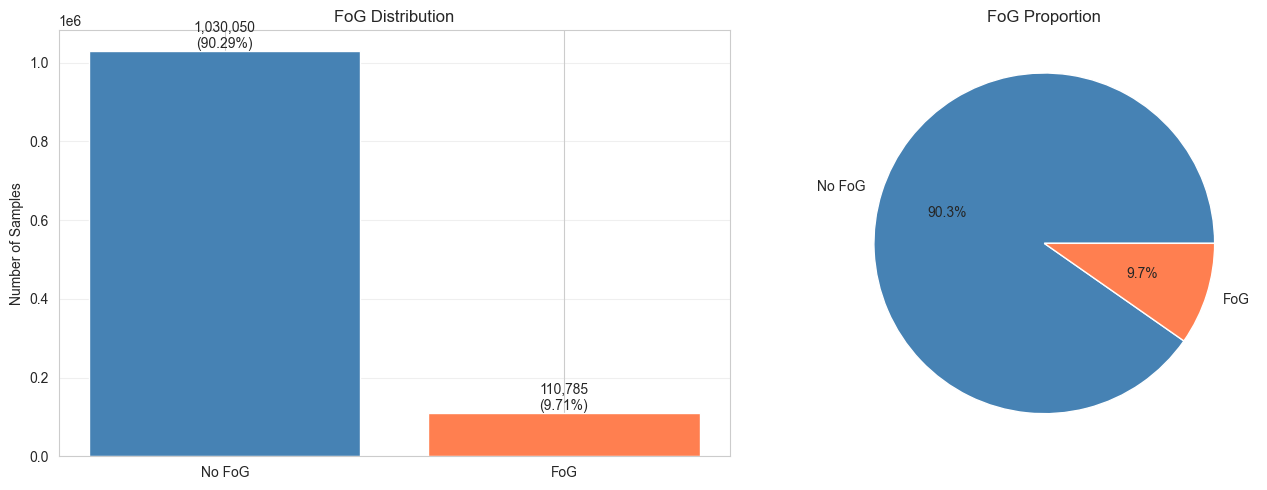

In [7]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1.bar(['No FoG', 'FoG'], fog_counts.values, color=['steelblue', 'coral'])
ax1.set_ylabel('Number of Samples')
ax1.set_title('FoG Distribution')
ax1.grid(axis='y', alpha=0.3)
for i, (count, pct) in enumerate(zip(fog_counts.values, fog_pct.values)):
    ax1.text(i, count, f'{count:,}\n({pct}%)', ha='center', va='bottom')

# Pie chart
ax2.pie(fog_counts.values, labels=['No FoG', 'FoG'], autopct='%1.1f%%',
        colors=['steelblue', 'coral'])
ax2.set_title('FoG Proportion')

plt.tight_layout()
plt.show()

## 4. Subject-Level Analysis

In [8]:
# Samples per subject
subject_summary = df.groupby('subject').agg({
    'time_s': 'count',
    'annotation': lambda x: (x == 2).sum()
}).rename(columns={'time_s': 'total_samples', 'annotation': 'fog_samples'})

subject_summary['fog_percentage'] = (subject_summary['fog_samples'] / 
                                      subject_summary['total_samples'] * 100).round(2)

print("Subject Statistics:")
print(subject_summary)

Subject Statistics:
         total_samples  fog_samples  fog_percentage
subject                                            
S01             121603         6694            5.50
S02              90562        11609           12.82
S03             128644        18340           14.26
S04             132482            0            0.00
S05             133766        30370           22.70
S06             127365         8413            6.61
S07             103042         5213            5.06
S08              49284        12859           26.09
S09             111365        17287           15.52
S10             142722            0            0.00


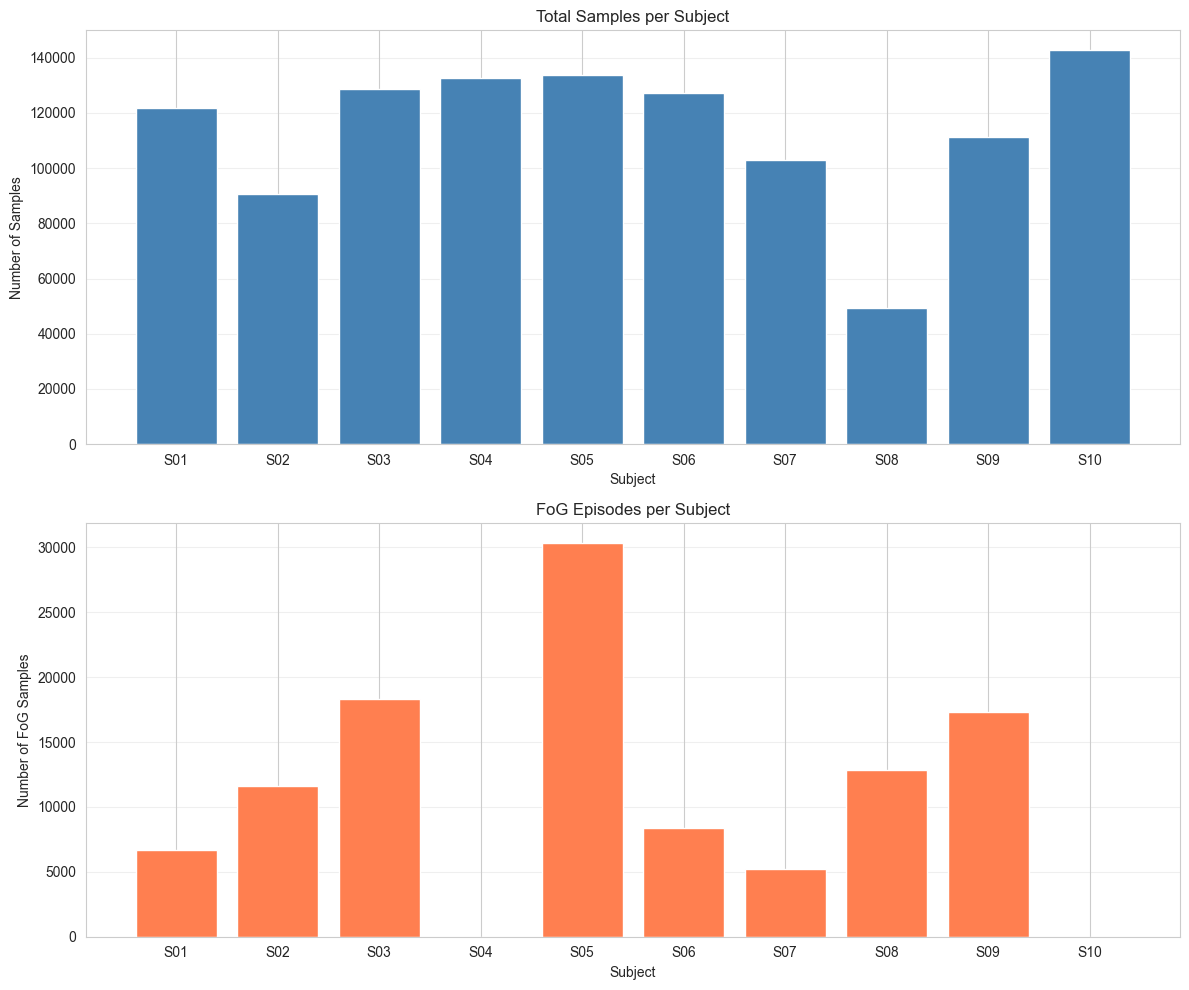

In [9]:
# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Total samples per subject
ax1.bar(subject_summary.index, subject_summary['total_samples'], color='steelblue')
ax1.set_xlabel('Subject')
ax1.set_ylabel('Number of Samples')
ax1.set_title('Total Samples per Subject')
ax1.grid(axis='y', alpha=0.3)

# FoG samples per subject
ax2.bar(subject_summary.index, subject_summary['fog_samples'], color='coral')
ax2.set_xlabel('Subject')
ax2.set_ylabel('Number of FoG Samples')
ax2.set_title('FoG Episodes per Subject')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Sensor Data Analysis

In [10]:
# Sensor columns
sensor_cols = [col for col in df.columns if 'acc' in col]
print("Sensor measurements:")
for col in sensor_cols:
    print(f"  {col}")

Sensor measurements:
  ankle_acc_forward
  ankle_acc_vertical
  ankle_acc_lateral
  thigh_acc_forward
  thigh_acc_vertical
  thigh_acc_lateral
  trunk_acc_forward
  trunk_acc_vertical
  trunk_acc_lateral


In [11]:
# Compare sensor statistics for FoG vs No FoG
fog_data = df[df['annotation'] == 2][sensor_cols]
no_fog_data = df[df['annotation'] == 1][sensor_cols]

print("Sensor Statistics Comparison (Mean):")
print("\nNo FoG:")
print(no_fog_data.mean())
print("\nFoG:")
print(fog_data.mean())

Sensor Statistics Comparison (Mean):

No FoG:
ankle_acc_forward    -109.477207
ankle_acc_vertical    996.201184
ankle_acc_lateral     244.643172
thigh_acc_forward       5.439395
thigh_acc_vertical    746.475208
thigh_acc_lateral     149.162303
trunk_acc_forward      60.931649
trunk_acc_vertical    954.416052
trunk_acc_lateral      27.194178
dtype: float64

FoG:
ankle_acc_forward       13.371215
ankle_acc_vertical    1003.102108
ankle_acc_lateral      223.830031
thigh_acc_forward      -72.733448
thigh_acc_vertical     970.395243
thigh_acc_lateral      122.343124
trunk_acc_forward        1.277095
trunk_acc_vertical     997.073449
trunk_acc_lateral      -76.803647
dtype: float64


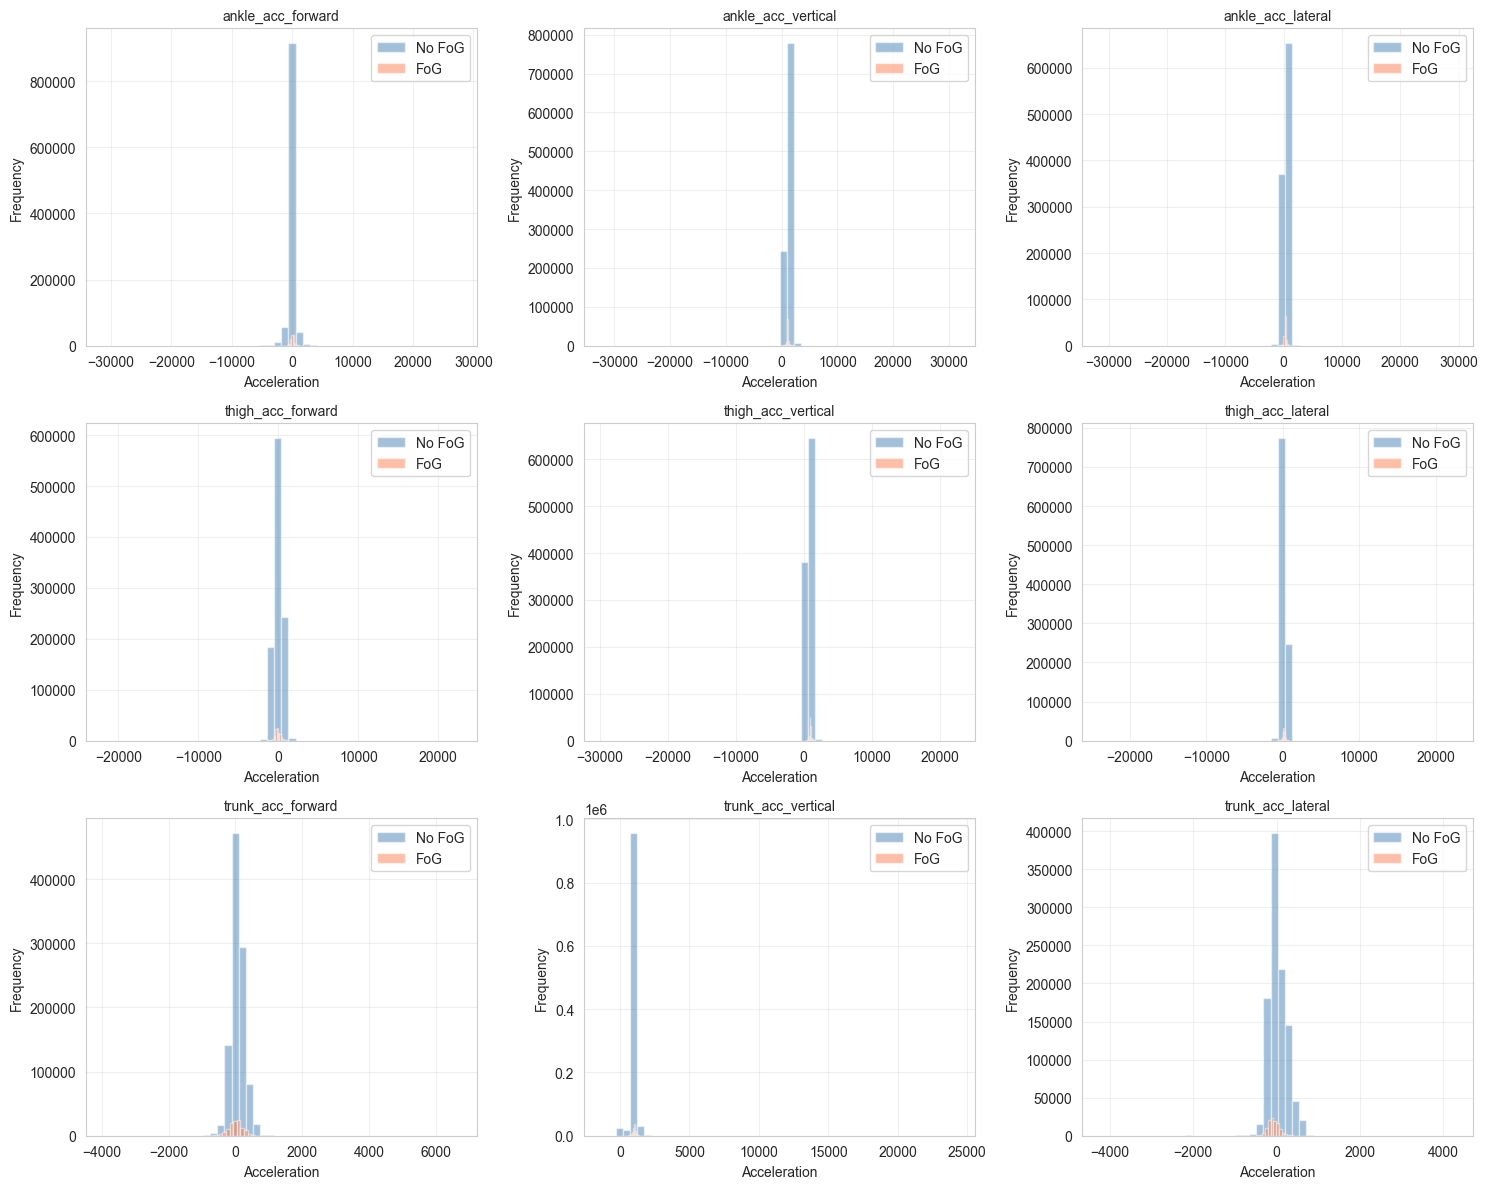

In [12]:
# Visualize sensor distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(sensor_cols):
    axes[i].hist(no_fog_data[col], bins=50, alpha=0.5, label='No FoG', color='steelblue')
    axes[i].hist(fog_data[col], bins=50, alpha=0.5, label='FoG', color='coral')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Acceleration')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation Analysis

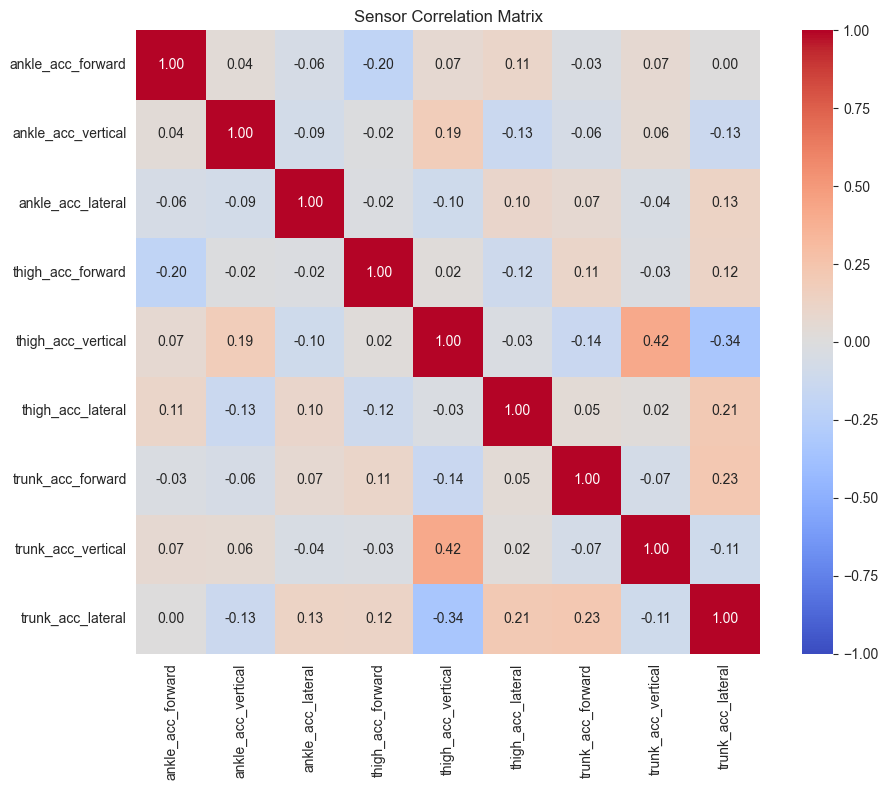

In [13]:
# Correlation matrix
corr_matrix = df[sensor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Sensor Correlation Matrix')
plt.tight_layout()
plt.show()

## 7. Temporal Patterns - Example FoG Episode

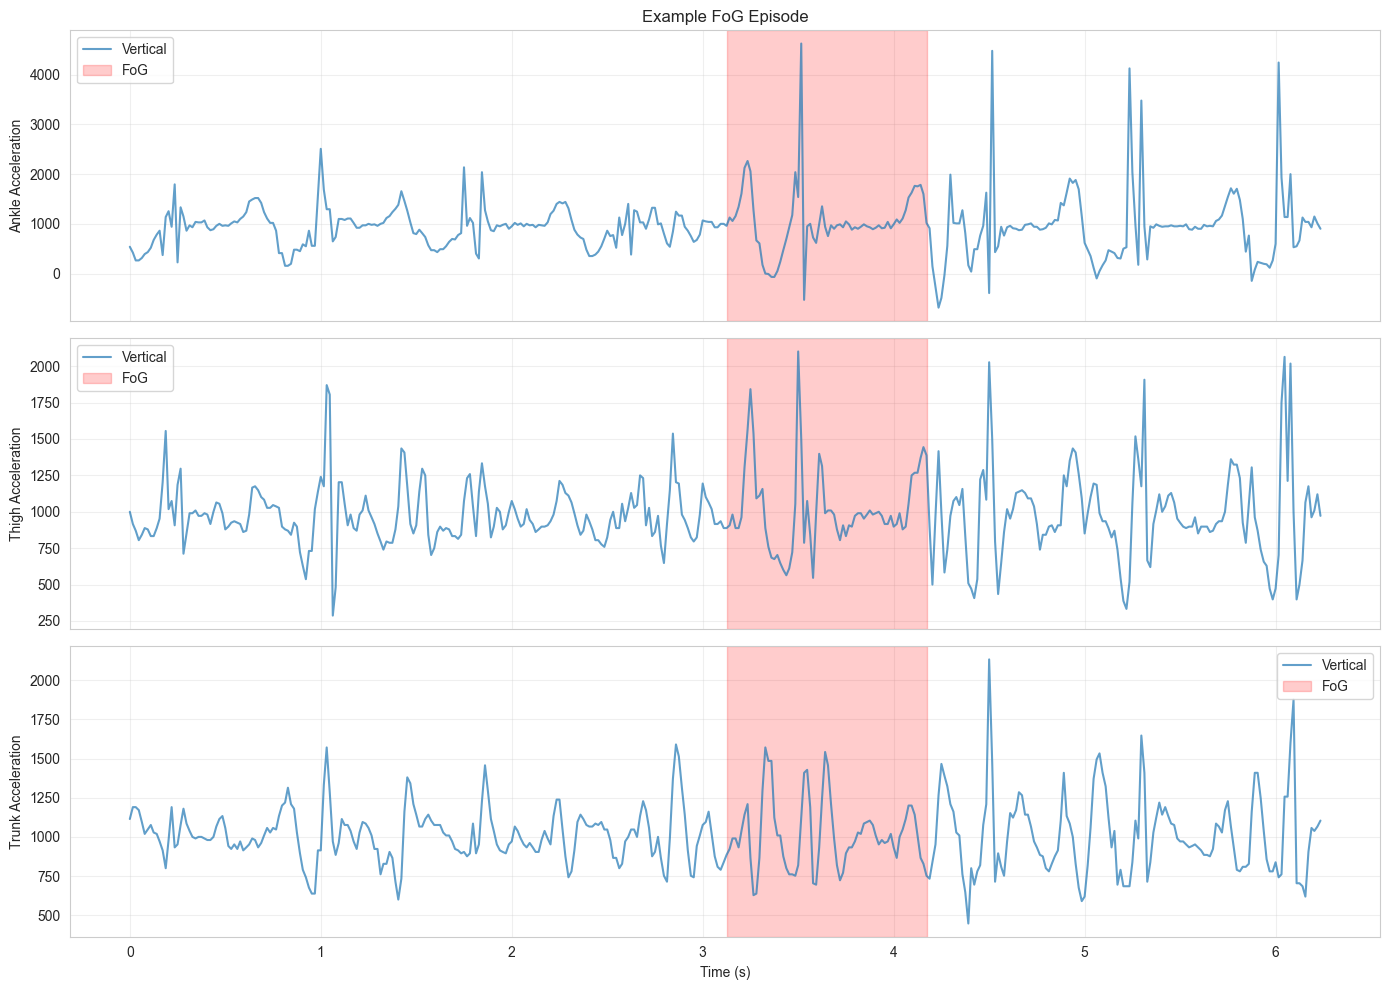

In [14]:
# Find a FoG episode and plot signals
subject = 'S01'
trial = 'R01'
mask = (df['subject'] == subject) & (df['trial'] == trial)
episode_data = df[mask].reset_index(drop=True)

# Find first FoG episode
fog_indices = episode_data[episode_data['annotation'] == 2].index
if len(fog_indices) > 0:
    # Take 400 samples around FoG
    center = fog_indices[0]
    start = max(0, center - 200)
    end = min(len(episode_data), center + 200)
    window = episode_data.iloc[start:end]
    
    # Plot
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    time = window['time_s'].values - window['time_s'].values[0]
    
    # Ankle
    axes[0].plot(time, window['ankle_acc_vertical'], label='Vertical', alpha=0.7)
    axes[0].axvspan(time[window['annotation']==2].min(), 
                     time[window['annotation']==2].max(), 
                     alpha=0.2, color='red', label='FoG')
    axes[0].set_ylabel('Ankle Acceleration')
    axes[0].set_title('Example FoG Episode')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Thigh
    axes[1].plot(time, window['thigh_acc_vertical'], label='Vertical', alpha=0.7)
    axes[1].axvspan(time[window['annotation']==2].min(), 
                     time[window['annotation']==2].max(), 
                     alpha=0.2, color='red', label='FoG')
    axes[1].set_ylabel('Thigh Acceleration')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Trunk
    axes[2].plot(time, window['trunk_acc_vertical'], label='Vertical', alpha=0.7)
    axes[2].axvspan(time[window['annotation']==2].min(), 
                     time[window['annotation']==2].max(), 
                     alpha=0.2, color='red', label='FoG')
    axes[2].set_ylabel('Trunk Acceleration')
    axes[2].set_xlabel('Time (s)')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"No FoG episodes found in {subject} {trial}")

## Summary

**Key Findings:**
1. Severe class imbalance: FoG represents ~10% of samples
2. Subject variability: Different patients show different FoG patterns
3. Sensor correlation: High correlation within sensor locations
4. FoG characteristics visible in acceleration patterns

**Implications for ML:**
- Need to address class imbalance (SMOTE, class weights)
- Subject-independent validation critical (LOSO)
- Feature engineering from all three sensors important
- Temporal patterns suggest window-based approach